In [10]:
"""
Scattered integrator — advection-diffusion PDE:
    u_t + c * u_x = alpha * u_xx,   x in [0,1],  t in [0,T]

Design
------
- FD grid is used as a coordinate scaffold only. Candidate points are
  drawn from FD grid coordinates so coverage is always dense.
- u values at interior points are computed by PDE-informed interpolation,
  NOT copied from FD. FD is used only for error measurement.
- Stopping criterion: max_points successfully computed interior points.
- KDTree for O(log N) neighbour queries.
- O(1) candidate removal via swap-and-pop.
"""

import time
import numpy as np
from scipy.spatial import KDTree
from scipy.interpolate import RegularGridInterpolator

# ── PDE parameters ────────────────────────────────────────────────────────────
alpha = 0.05
c     = 0.5
T     = 1

def u_true(x, t):
    """Exact solution — replace with your actual IC/BC."""
    return np.sin(np.pi * x) * np.exp(-(alpha * np.pi**2 + c) * t)


# ── FD reference grid ─────────────────────────────────────────────────────────
nx_fd = 100
x_fd  = np.linspace(0.0, 1.0, nx_fd)
dx_fd = x_fd[1] - x_fd[0]

# Compute nt_fd from CFL — never touch this manually
dt_cfl = min(0.9  * dx_fd / c,
             0.45 * dx_fd**2 / alpha)
nt_fd  = max(int(np.ceil(T / dt_cfl)) + 1, 10)
t_fd   = np.linspace(0.0, T, nt_fd)
dt_fd  = t_fd[1] - t_fd[0]



def build_fd_reference():
    """Explicit upwind FD solve. Returns (u_fd, interpolant)."""
    u = np.zeros((nx_fd, nt_fd))
    u[:, 0] = u_true(x_fd, 0.0)

    r_diff = alpha * dt_fd / dx_fd**2
    r_adv  = c     * dt_fd / dx_fd

    for it in range(nt_fd - 1):
        un = u[:, it]
        u[1:-1, it+1] = (un[1:-1]
                         - r_adv  * (un[1:-1] - un[:-2])
                         + r_diff * (un[2:] - 2*un[1:-1] + un[:-2]))
        u[0,  it+1] = 0.0
        u[-1, it+1] = 0.0

    interp = RegularGridInterpolator(
        (x_fd, t_fd), u, method='linear',
        bounds_error=False, fill_value=None
    )
    return u, interp


# ── Integrator hyperparameters ────────────────────────────────────────────────
max_points    = 20000   # stopping criterion
u_bound = 1.1
n_neighbours  = 5       # stencil size (3 equations, 5 unknowns → underdetermined)
cond_max      = 1e4
isotropy_max  = 50.0
w_max_factor  = 3.0     # reject if max|w_j| > w_max_factor / n
w_min_floor   = -1.0

# Spawn box in FD grid steps
spawn_nx      = 5       # ± x steps around a newly solved point
spawn_nt      = 3       # + t steps forward

# Neighbour search box in normalised units (x/dx_fd, t/dt_fd)
box_n0        = 2.0     # initial half-width
box_grow      = 1.5
box_nmax      = 15.0

max_candidates = 10_000


# ── KDTree-backed visited set ─────────────────────────────────────────────────
class VisitedSet:
    """
    Stores (x, t, u) points. KDTree is in normalised (x/dx_fd, t/dt_fd)
    space so both axes are commensurate during neighbour search.
    Rebuilt lazily every rebuild_every insertions.
    """
    def __init__(self, rebuild_every=200):
        self._pts           = []
        self._tree          = None
        self._dirty         = 0
        self._rebuild_every = rebuild_every

    def add(self, x, t, u):
        self._pts.append((x, t, u))
        self._dirty += 1
        if self._dirty >= self._rebuild_every:
            self._rebuild()

    def _rebuild(self):
        norm        = np.array([[p[0]/dx_fd, p[1]/dt_fd] for p in self._pts])
        self._tree  = KDTree(norm)
        self._dirty = 0

    def _ensure(self):
        if self._tree is None or self._dirty > 0:
            self._rebuild()

    def find_neighbours(self, x_star, t_star):
        """
        Expanding normalised-box search.
        Returns list of n_neighbours (x, t, u) tuples, or None.
        """
        self._ensure()
        xn = x_star / dx_fd
        tn = t_star / dt_fd
        bn = box_n0

        while True:
            idxs = self._tree.query_ball_point([xn, tn], r=bn, p=np.inf)
            nb = [
                self._pts[i] for i in idxs
                if abs(self._pts[i][0] - x_star) <= bn * dx_fd
                and 0 < (t_star - self._pts[i][1]) <= bn * dt_fd
            ]
            if len(nb) >= n_neighbours:
                nb.sort(key=lambda p: (p[0]-x_star)**2 + (p[1]-t_star)**2)
                return nb[:n_neighbours]

            bn = min(bn * box_grow, box_nmax)
            if bn >= box_nmax:
                return None

    def is_too_close(self, x, t, tol=0.4):
        """True if (x,t) is within tol grid cells of any visited point."""
        self._ensure()
        idxs = self._tree.query_ball_point([x/dx_fd, t/dt_fd], r=tol, p=np.inf)
        return len(idxs) > 0

    def __len__(self):
        return len(self._pts)


# ── Stencil geometry check ────────────────────────────────────────────────────
def stencil_is_good(dx_i, dt_i):
    if np.min(dx_i) * np.max(dx_i) > 0:          # two-sided coverage
        return False
    if np.max(dx_i) - np.min(dx_i) < 0.9 * dx_fd: # minimum span
        return False
    h   = max(np.max(np.abs(dx_i)), 1e-12)
    tau = max(np.max(np.abs(dt_i)), 1e-12)
    pts = np.column_stack([dx_i / h, dt_i / tau])
    ev  = np.linalg.eigvalsh(pts.T @ pts)
    if ev[0] < 1e-14 or ev[1] / ev[0] > isotropy_max:
        return False
    return True


# ── Weight solver ─────────────────────────────────────────────────────────────
def solve_weights(dx_i, dt_i):
    """
    Min-norm lstsq on the 3×n PDE-informed system.
    Returns (w, cond) or (None, cond).
    """
    h   = max(np.max(np.abs(dx_i)), 1e-12)
    tau = max(np.max(np.abs(dt_i)), 1e-12)

    A = np.array([
        np.ones(len(dx_i)),
        (dx_i - c * dt_i)              / h,
        (0.5 * dx_i**2 + alpha * dt_i) / h**2,
    ])  # (3, n)
    b = np.array([1.0, 0.0, 0.0])

    cond = np.linalg.cond(A)
    if cond > cond_max:
        return None, cond

    w = np.linalg.lstsq(A, b, rcond=None)[0]

    if abs(np.sum(w) - 1.0) > 1e-6:                    # partition of unity
        return None, cond
    if np.max(np.abs(w)) > w_max_factor / len(dx_i):   # no dominant weight
        return None, cond
    if np.min(w) < w_min_floor:                         # no extreme negatives
        return None, cond

    return w, cond


# ── Main integrator ───────────────────────────────────────────────────────────
def run_integrator(seed=None):
    t_wall = time.time()
    if seed is not None:
        np.random.seed(seed)

    print("Building FD reference...", flush=True)
    _, fd_interp = build_fd_reference()
    print(f"  dx={dx_fd:.4f}  dt={dt_fd:.5f}", flush=True)

    # IC + BC into visited set
    visited = VisitedSet()
    for ix in range(nx_fd):
        visited.add(x_fd[ix], 0.0, u_true(x_fd[ix], 0.0))
    for it in range(1, nt_fd):
        visited.add(0.0,  t_fd[it], 0.0)
        visited.add(1.0,  t_fd[it], 0.0)
    print(f"  IC+BC points: {len(visited)}", flush=True)

    # Candidate pool — integer (ix, it) keys for O(1) deduplication
    cand_keys = set()
    cand_list = []   # list of (x, t)

    def push(ix, it):
        if (ix, it) not in cand_keys:
            cand_keys.add((ix, it))
            cand_list.append((x_fd[ix], t_fd[it]))

    # Seed from IC
    for ix in range(1, nx_fd - 1):
        for dix in range(-spawn_nx, spawn_nx + 1):
            for dit in range(1, spawn_nt + 1):
                nix, nit = ix + dix, dit
                if 1 <= nix <= nx_fd - 2 and nit < nt_fd:
                    push(nix, nit)

    print(f"  Initial candidates: {len(cand_list)}", flush=True)
    print(f"  Stopping at {max_points} computed points\n", flush=True)

    rej        = dict(proximity=0, no_nb=0, geometry=0, cond=0, weights=0)
    point_data = []

    while cand_list and len(point_data) < max_points:

        # Trim if candidate list is over budget
        if len(cand_list) > max_candidates:
            del cand_list[:len(cand_list) - max_candidates]

        # ── O(1) swap-and-pop ─────────────────────────────────────────────
        idx            = np.random.randint(len(cand_list))
        x_star, t_star = cand_list[idx]
        cand_list[idx] = cand_list[-1]
        cand_list.pop()
        ix_s = int(round(x_star / dx_fd))
        it_s = int(round(t_star / dt_fd))
        cand_keys.discard((ix_s, it_s))
        # ─────────────────────────────────────────────────────────────────

        if visited.is_too_close(x_star, t_star):
            rej['proximity'] += 1
            continue

        nb = visited.find_neighbours(x_star, t_star)
        if nb is None:
            rej['no_nb'] += 1
            continue

        nb_pts = np.array(nb)
        dx_i   = nb_pts[:, 0] - x_star
        dt_i   = nb_pts[:, 1] - t_star   # negative: neighbours are in the past

        if not stencil_is_good(dx_i, dt_i):
            rej['geometry'] += 1
            continue

        w, cond = solve_weights(dx_i, dt_i)
        if w is None:
            rej['cond' if cond > cond_max else 'weights'] += 1
            continue

        # ── Accept point ──────────────────────────────────────────────────
        u_hat = float(w @ nb_pts[:, 2])

        # Break the error cascade — u is bounded by IC amplitude + margin
        if abs(u_hat) > u_bound:
            rej['bounds'] = rej.get('bounds', 0) + 1
            continue

        visited.add(x_star, t_star, u_hat)

        # Spawn new candidates in the FD grid box around this point
        for dix in range(-spawn_nx, spawn_nx + 1):
            for dit in range(1, spawn_nt + 1):
                nix = ix_s + dix
                nit = it_s + dit
                if 1 <= nix <= nx_fd - 2 and nit < nt_fd:
                    push(nix, nit)

        u_ref = float(fd_interp([[x_star, t_star]])[0])
 
        point_data.append({
            'x':     x_star,
            't':     t_star,
            'u':     u_hat,
            'err':   abs(u_hat - u_ref),
            'cond':  cond,
            'w1':    float(np.sum(np.abs(w))),
            'box_x': float(np.max(np.abs(dx_i))),   # ← add this
            'box_t': float(np.max(np.abs(dt_i))),   # ← add this
            'nb_x':  nb_pts[:, 0].copy(),            # ← add
            'nb_t':  nb_pts[:, 1].copy(),            # ← add
            'nb_u':  nb_pts[:, 2].copy(),            # ← add
        })

        if len(point_data) % 500 == 0:
            errs = [p['err'] for p in point_data]
            t_max = max(p['t'] for p in point_data)
            print(f"  {len(point_data):5d} pts | "
                  f"mean={np.mean(errs):.2e} | "
                  f"max={np.max(errs):.2e} | "
                  f"t_max={t_max:.3f} | "
                  f"cands={len(cand_list):5d} | "
                  f"wall={time.time()-t_wall:.1f}s",
                  flush=True)

    # ── Summary ───────────────────────────────────────────────────────────────
    errs = np.array([p['err'] for p in point_data])
    print(f"\n{'─'*56}")
    print(f"  Computed  : {len(point_data)} points")
    print(f"  Mean err  : {errs.mean():.3e}")
    print(f"  Max  err  : {errs.max():.3e}")
    print(f"  Wall time : {time.time()-t_wall:.1f}s")
    total = sum(rej.values()) + len(point_data)
    print(f"\n  Rejections (total attempts: {total})")
    for r, n in rej.items():
        print(f"    {r:10s}: {n:6d}  ({100*n/total:.1f}%)")

    return visited, point_data, fd_interp


if __name__ == '__main__':
    visited, point_data, fd_interp = run_integrator()

Building FD reference...
  dx=0.0101  dt=0.00092
  IC+BC points: 2278
  Initial candidates: 294
  Stopping at 20000 computed points

    500 pts | mean=2.29e-04 | max=1.91e-03 | t_max=0.032 | cands= 2347 | wall=1.3s
   1000 pts | mean=3.32e-04 | max=2.57e-03 | t_max=0.040 | cands= 3368 | wall=2.6s
   1500 pts | mean=4.08e-04 | max=3.22e-03 | t_max=0.054 | cands= 4197 | wall=4.1s
   2000 pts | mean=4.67e-04 | max=3.22e-03 | t_max=0.065 | cands= 4805 | wall=5.7s
   2500 pts | mean=5.16e-04 | max=3.22e-03 | t_max=0.068 | cands= 5165 | wall=7.9s
   3000 pts | mean=5.44e-04 | max=3.22e-03 | t_max=0.072 | cands= 5457 | wall=10.3s
   3500 pts | mean=5.79e-04 | max=3.22e-03 | t_max=0.078 | cands= 5665 | wall=12.9s
   4000 pts | mean=6.07e-04 | max=3.22e-03 | t_max=0.081 | cands= 5676 | wall=15.6s
   4500 pts | mean=6.29e-04 | max=3.22e-03 | t_max=0.081 | cands= 5966 | wall=19.0s
   5000 pts | mean=6.49e-04 | max=3.22e-03 | t_max=0.081 | cands= 6058 | wall=22.5s
   5500 pts | mean=6.80e-04 | ma

c:\Users\user\OneDrive\RL For PDEs\Taylor linear predictor\Plots\interactive_plot.py:152: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax_right.legend(fontsize=9, framealpha=0.9, edgecolor='#CCCCCC')


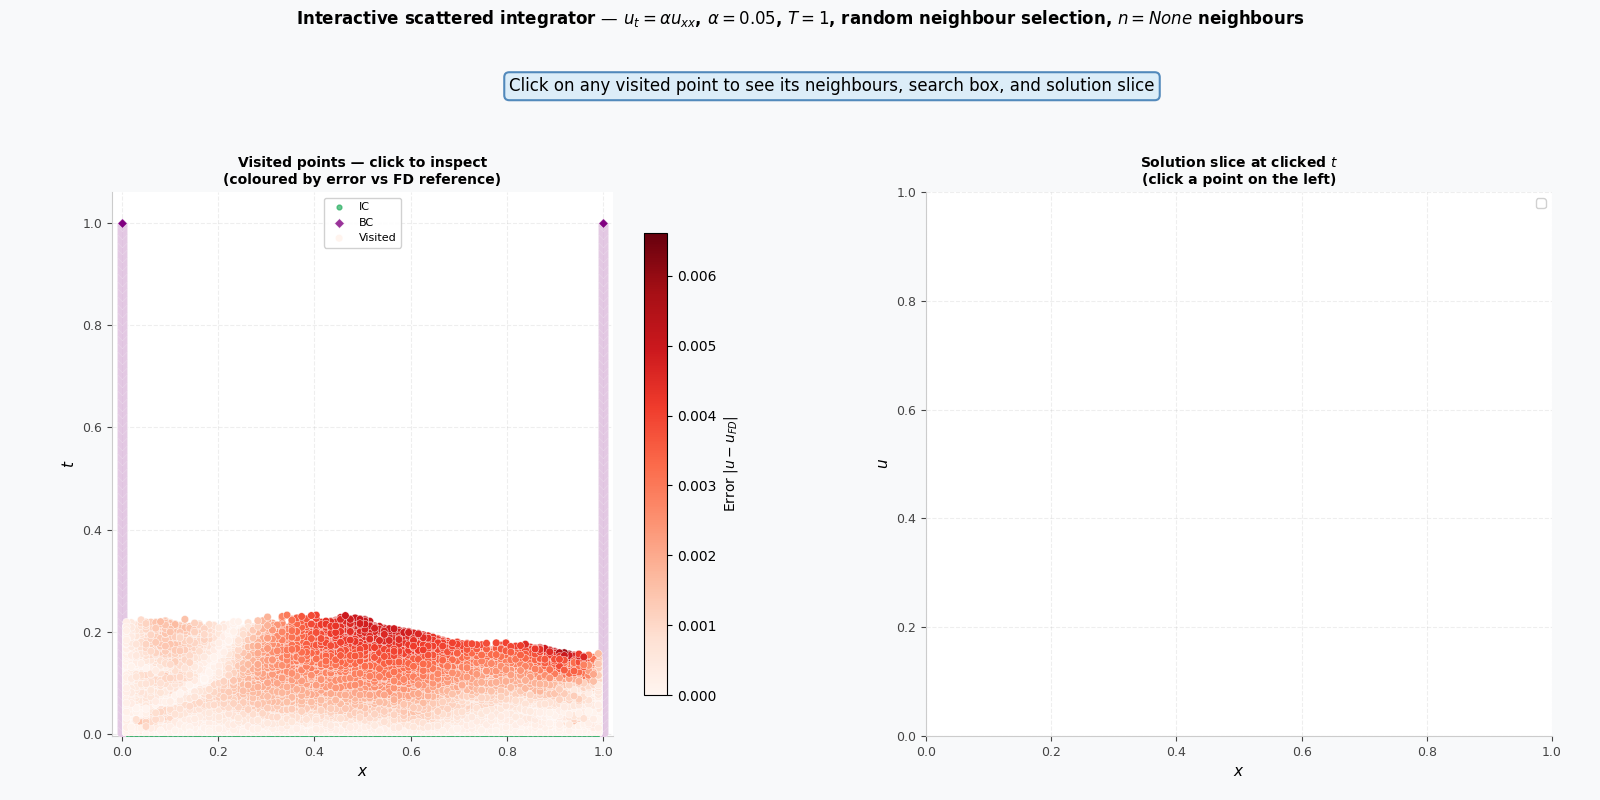

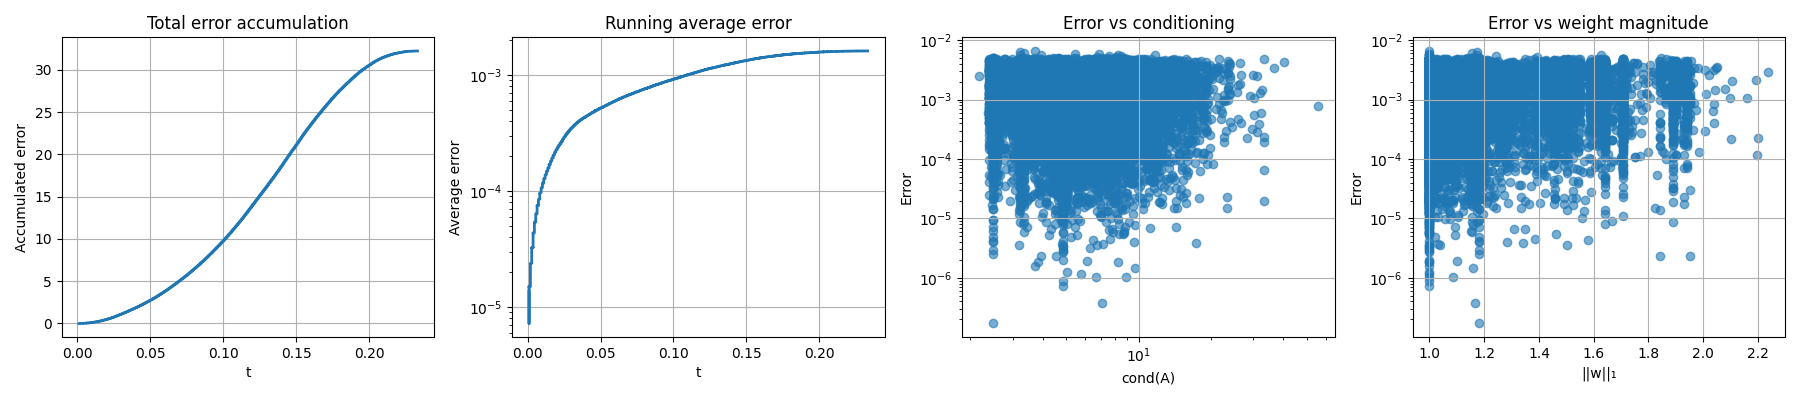

In [11]:
%matplotlib widget
from Plots.interactive_plot import interactive_plot
from Plots.error_analysis import error_analysis

# Extract IC and BC coordinates from visited._pts
ic_x = np.array([p[0] for p in visited._pts if p[1] == 0.0 and 0 < p[0] < 1.0])
ic_t = np.array([p[1] for p in visited._pts if p[1] == 0.0 and 0 < p[0] < 1.0])

bc_x = np.array([p[0] for p in visited._pts if p[0] in [0.0, 1.0]])
bc_t = np.array([p[1] for p in visited._pts if p[0] in [0.0, 1.0]])

interactive_plot(
    point_data,
    visited._pts,   # pass the raw list so the plot code sees (x, t, u) tuples
    u_true,
    fd_interp,
    T,
    dt_fd,          # was dt_sc
    ic_x,
    ic_t,
    bc_x,
    bc_t
)

error_analysis(point_data)

# Convergence study 
## Fix a fine reference grid, sweep candidate spacing via stride.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

T             = 1
n_max         = 5000
strides       = [1, 2, 4, 8]    # ← added 8
nx_fd_cv      = 400
max_points_cv = 2_000
cv_seed       = 42

# Save original globals so we can restore after the study
_orig = {k: globals()[k] for k in
         ['nx_fd','x_fd','dx_fd','nt_fd','t_fd','dt_fd','max_points']}

# ── Local stencil check that accepts coarser span_ref ────────────────────────
def stencil_is_good_cv(dx_i, dt_i, span_ref):
    if np.min(dx_i) * np.max(dx_i) > 0:
        return False
    if np.max(dx_i) - np.min(dx_i) < 0.9 * span_ref:   # uses effective dx
        return False
    h   = max(np.max(np.abs(dx_i)), 1e-12)
    tau = max(np.max(np.abs(dt_i)), 1e-12)
    pts = np.column_stack([dx_i / h, dt_i / tau])
    ev  = np.linalg.eigvalsh(pts.T @ pts)
    if ev[0] < 1e-14 or ev[1] / ev[0] > isotropy_max:
        return False
    return True

# ── Fix reference grid ────────────────────────────────────────────────────────
nx_fd  = nx_fd_cv
x_fd   = np.linspace(0.0, 1.0, nx_fd)
dx_fd  = x_fd[1] - x_fd[0]
dt_cfl = min(0.9 * dx_fd / c, 0.45 * dx_fd**2 / alpha)
nt_fd  = max(int(np.ceil(T / dt_cfl)) + 1, 10)
t_fd   = np.linspace(0.0, T, nt_fd)
dt_fd  = t_fd[1] - t_fd[0]
max_points = max_points_cv

print(f"Reference grid: nx={nx_fd}, nt={nt_fd}, dx={dx_fd:.4f}, dt={dt_fd:.5f}")
print(f"CFL — advection: {c*dt_fd/dx_fd:.3f}, diffusion: {alpha*dt_fd/dx_fd**2:.3f}\n")

cv_results = []   # (effective_dx, mean_err, max_err)

for stride in strides:
    eff_dx = stride * dx_fd
    print(f"Stride {stride}  — effective dx={eff_dx:.4f}", flush=True)

    _, fd_interp_cv = build_fd_reference()

    visited_cv = VisitedSet()
    for ix in range(nx_fd):
        visited_cv.add(x_fd[ix], 0.0, u_true(x_fd[ix], 0.0))
    for it in range(1, nt_fd):
        visited_cv.add(0.0, t_fd[it], 0.0)
        visited_cv.add(1.0, t_fd[it], 0.0)

    cand_keys = set()
    cand_list = []

    def push_cv(ix, it):
        if ix % stride != 0 or it % stride != 0:
            return
        if (ix, it) not in cand_keys:
            cand_keys.add((ix, it))
            cand_list.append((x_fd[ix], t_fd[it]))

    np.random.seed(cv_seed)
    for ix in range(stride, nx_fd - 1, stride):
        for dix in range(-spawn_nx, spawn_nx + 1):
            for dit in range(1, spawn_nt + 1):
                nix = ix + dix * stride
                nit = dit * stride
                if 1 <= nix <= nx_fd - 2 and nit < nt_fd:
                    push_cv(nix, nit)

    rej = dict(proximity=0, no_nb=0, geometry=0, cond=0, weights=0, bounds=0)
    point_data_cv = []

    while cand_list and len(point_data_cv) < max_points_cv:
        if len(cand_list) > max_candidates:
            del cand_list[:len(cand_list) - max_candidates]

        idx            = np.random.randint(len(cand_list))
        x_star, t_star = cand_list[idx]
        cand_list[idx] = cand_list[-1]
        cand_list.pop()
        ix_s = int(round(x_star / dx_fd))
        it_s = int(round(t_star / dt_fd))
        cand_keys.discard((ix_s, it_s))

        if visited_cv.is_too_close(x_star, t_star):
            rej['proximity'] += 1
            continue

        nb = visited_cv.find_neighbours(x_star, t_star)
        if nb is None:
            rej['no_nb'] += 1
            continue

        nb_pts = np.array(nb)
        dx_i   = nb_pts[:, 0] - x_star
        dt_i   = nb_pts[:, 1] - t_star

        if not stencil_is_good_cv(dx_i, dt_i, span_ref=eff_dx):   # ← passes eff_dx
            rej['geometry'] += 1
            continue

        w, cond = solve_weights(dx_i, dt_i)
        if w is None:
            rej['cond' if cond > cond_max else 'weights'] += 1
            continue

        u_hat = float(w @ nb_pts[:, 2])
        if abs(u_hat) > u_bound:
            rej['bounds'] += 1
            continue

        visited_cv.add(x_star, t_star, u_hat)

        for dix in range(-spawn_nx, spawn_nx + 1):
            for dit in range(1, spawn_nt + 1):
                nix = ix_s + dix * stride
                nit = it_s + dit * stride
                if 1 <= nix <= nx_fd - 2 and nit < nt_fd:
                    push_cv(nix, nit)

        u_ref = float(fd_interp_cv([[x_star, t_star]])[0])
        point_data_cv.append({'err': abs(u_hat - u_ref)})

    # ── Guard against empty results ───────────────────────────────────────────
    if len(point_data_cv) == 0:
        print(f"  pts=0 — all candidates rejected at this stride")
        cv_results.append((eff_dx, np.nan, np.nan))
        continue

    errs = np.array([p['err'] for p in point_data_cv])
    print(f"  pts={len(point_data_cv)}, mean={errs.mean():.3e}, max={errs.max():.3e}")
    total = sum(rej.values()) + len(point_data_cv)
    for r, n in rej.items():
        if n > 0:
            print(f"    {r:10s}: {n} ({100*n/total:.0f}%)")
    cv_results.append((eff_dx, errs.mean(), errs.max()))

# Restore original globals
for k, v in _orig.items():
    globals()[k] = v

# ── Plot — skip any nan entries ───────────────────────────────────────────────
valid = [(dx, me, mx) for dx, me, mx in cv_results if not np.isnan(me)]

if len(valid) < 2:
    print("Not enough valid strides to plot — check rejection stats above.")
else:
    dxs   = np.array([r[0] for r in valid])
    means = np.array([r[1] for r in valid])
    maxes = np.array([r[2] for r in valid])

    fig, ax = plt.subplots(figsize=(6, 4))
    ax.loglog(dxs, means, 'o-',  label='mean error')
    ax.loglog(dxs, maxes, 's--', label='max error')

    for order, ls, label in [(1, ':', 'O(dx)'), (2, '-.', 'O(dx²)')]:
        ref = means[0] * (dxs / dxs[0])**order
        ax.loglog(dxs, ref, color='gray', linestyle=ls, linewidth=0.8, label=label)

    ax.set_xlabel('Effective dx (your method)')
    ax.set_ylabel('Error vs FD reference')
    ax.set_title('Convergence study')
    ax.legend()
    ax.grid(True, which='both', alpha=0.3)
    plt.tight_layout()
    plt.show()

Reference grid: nx=400, nt=17690, dx=0.0025, dt=0.00006
CFL — advection: 0.011, diffusion: 0.450

Stride 1  — effective dx=0.0025
